# Setup

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from scipy.stats import norm

# Carregamento do arquivo csv

In [6]:
df = pd.read_csv('/content/charging_ev_and_grid_optimization_dataset (4).csv')

df.head()

,timestamp,station_id,location_type,vehicle_id,vehicle_type,arrival_time,charging_start_time,charging_end_time,waiting_time,battery_capacity_kWh,...,electricity_price,renewable_energy_ratio,traffic_density,weather_condition,day_of_week,time_slot,charging_demand,assigned_charger_id,charging_priority,optimization_reward
0,1/1/2025 0:00,ST004,Urban,EV10000,Two-Wheeler,1/1/2025 0:00,1/1/2025 0:12,1/1/2025 4:33,12,60,...,13.66,0.280335,Low,Cloudy,Wednesday,Off-Peak,17.242398,CH4,Low,-8.622299
1,1/1/2025 0:15,ST005,Urban,EV10001,Two-Wheeler,1/1/2025 0:15,1/1/2025 0:23,1/1/2025 1:12,8,100,...,5.47,0.392127,Low,Rainy,Wednesday,Off-Peak,18.324933,CH9,Low,-1.935644
2,1/1/2025 0:30,ST019,Highway,EV10002,Car,1/1/2025 0:30,1/1/2025 0:41,1/1/2025 1:35,11,75,...,9.50,0.103979,Low,Clear,Wednesday,Off-Peak,36.028168,CH2,Low,-18.201846
3,1/1/2025 0:45,ST008,Urban,EV10003,Two-Wheeler,1/1/2025 0:45,1/1/2025 0:54,1/1/2025 3:29,9,40,...,6.22,0.248553,Low,Clear,Wednesday,Off-Peak,17.146935,CH9,Medium,-7.404018
4,1/1/2025 1:00,ST008,Highway,EV10004,Two-Wheeler,1/1/2025 1:00,1/1/2025 1:08,1/1/2025 6:14,8,75,...,13.42,0.234926,Low,Cloudy,Wednesday,Off-Peak,14.577768,CH1,Low,-6.577466


In [7]:
print(df.columns)

Index(['timestamp', 'station_id', 'location_type', 'vehicle_id',
       'vehicle_type', 'arrival_time', 'charging_start_time',
       'charging_end_time', 'waiting_time', 'battery_capacity_kWh',
       'initial_soc', 'final_soc', 'energy_consumed_kWh', 'charging_power_kW',
       'charging_duration', 'queue_length', 'station_load',
       'electricity_price', 'renewable_energy_ratio', 'traffic_density',
       'weather_condition', 'day_of_week', 'time_slot', 'charging_demand',
       'assigned_charger_id', 'charging_priority', 'optimization_reward'],
      dtype='object')


## 01) Probabilidade acima da Mediana – 2,5 pontos

Realize a análise da probabilidade de ocorrência de valores acima da mediana da variável selecionada.


*   Cálculo correto da mediana;
*    Cálculo correto da probabilidade;
*   Código estruturado e resultados apresentados corretamente;
*   Classificação correta do evento como raro, pouco provável, provável ou quase certo.


In [8]:
# Váriavel númerica escolhida = 'energy_consumed_kWh'
consumo_energia = df['energy_consumed_kWh'].dropna()
# Removendo valores nulos
print(consumo_energia.head())

0    30.528616
1    41.504507
2    45.016306
3    28.291670
4    55.810835
Name: energy_consumed_kWh, dtype: float64


In [9]:
# Cáculo da mediana
mediana = consumo_energia.median()

print(f'A mediana é igual á {mediana:.3f}' )

A mediana é igual á 35.148


In [10]:
desvio = consumo_energia.std()
media = consumo_energia.mean()
# para probabilidade acima não dar erro

In [11]:
# Conta quantos valores estão estritamente acima da mediana
valores_acima = (consumo_energia > mediana).sum()

print(valores_acima)

4177


In [12]:
total_valores = consumo_energia.count()

print(total_valores)

8354


In [13]:
probabilidade = valores_acima / total_valores

print(f'A probabilidade real nos dados é: {probabilidade:.2%}')

A probabilidade real nos dados é: 50.00%


In [14]:
# Auxilio da IA

# ADICIONADO: o enunciado pede pra assumir Distribuição Normal, não só contar os dados reais.
# norm.cdf(x, loc, scale) devolve a probabilidade de um valor ser MENOR OU IGUAL a x,
prob_normal_acima_mediana = 1 - norm.cdf(mediana, loc=media, scale=desvio)

print(f'Probabilidade (Distribuição Normal) de valor acima da mediana: {prob_normal_acima_mediana:.2%}')

Probabilidade (Distribuição Normal) de valor acima da mediana: 58.21%


In [15]:
# Critério comum usado em estatística:
#   < 5%    -> Raro
#   5%-40%  -> Pouco provável
#   40%-90% -> Provável
#   > 90%   -> Quase certo

if prob_normal_acima_mediana < 0.05:
    classificacao = 'Raro'
elif prob_normal_acima_mediana < 0.40:
    classificacao = 'Pouco provável'
elif prob_normal_acima_mediana < 0.90:
    classificacao = 'Provável'
else:
    classificacao = 'Quase certo'

print(f'Classificação do evento: {classificacao}')

Classificação do evento: Provável


# 02) Probabilidade no intervalo (média ± 2s) – 2,5 pontos

Determine a probabilidade de a variável selecionada assumir valores dentro do intervalo definido por média ± 2 desvios-padrão.


*   Cálculo correto da média, do desvio-padrão e dos limites do intervalo;
*   Cálculo correto da probabilidade associada ao intervalo;
*   Código estruturado e resultados apresentados corretamente;
*   Classificação correta do evento como raro, pouco provável, provável ou quase certo.

In [16]:
media = consumo_energia.mean()

print(f'A média é igual á {media:.3f}')

A média é igual á 39.080


In [17]:
desvio = consumo_energia.std()

print(f'O desvio-padrão é igual á { desvio:.3f}')

O desvio-padrão é igual á 18.974


In [18]:
# Definição dos limites do intervalos
limite_inferior = media - 2 * desvio
limite_superior = media + 2 * desvio

print(f'Limite inferior: {limite_inferior:.3f}')
print(f'Limite superior: {limite_superior:.3f}')

Limite inferior: 1.132
Limite superior: 77.028


In [19]:
valores_no_intervalo = ((consumo_energia >= limite_inferior) & (consumo_energia <= limite_superior)).sum()

print(valores_no_intervalo)

7929


In [20]:
# Probabilidade associada ao intervalo
probabilidade_intervalo = valores_no_intervalo / total_valores

In [21]:
# mesma lógica do Ex.1, mas agora para um intervalon (entre dois limites).
# Pra calcular probabilidade "entre A e B", fazemos:
#   P(A <= X <= B) = P(X <= B) - P(X <= A)
prob_normal_intervalo = norm.cdf(limite_superior, media, desvio) - norm.cdf(limite_inferior, media, desvio)

print(f'Probabilidade (Distribuição Normal) no intervalo: {prob_normal_intervalo:.2%}')

Probabilidade (Distribuição Normal) no intervalo: 95.45%


In [22]:
if prob_normal_intervalo < 0.05:
    classificacao_intervalo = 'Raro'
elif prob_normal_intervalo < 0.40:
    classificacao_intervalo = 'Pouco provável'
elif prob_normal_intervalo < 0.90:
    classificacao_intervalo = 'Provável'
else:
    classificacao_intervalo = 'Quase certo'

print(f'Classificação do evento: {classificacao_intervalo}')

Classificação do evento: Quase certo


In [23]:
print(f'Média: {media:.3f}')
print(f'Desvio-Padrão: {desvio:.3f}')
print(f'Intervalo: [{limite_inferior:.3f} até {limite_superior:.3f}]')
print(f'Probabilidade no intervalo: {probabilidade_intervalo:.2%}')

Média: 39.080
Desvio-Padrão: 18.974
Intervalo: [1.132 até 77.028]
Probabilidade no intervalo: 94.91%


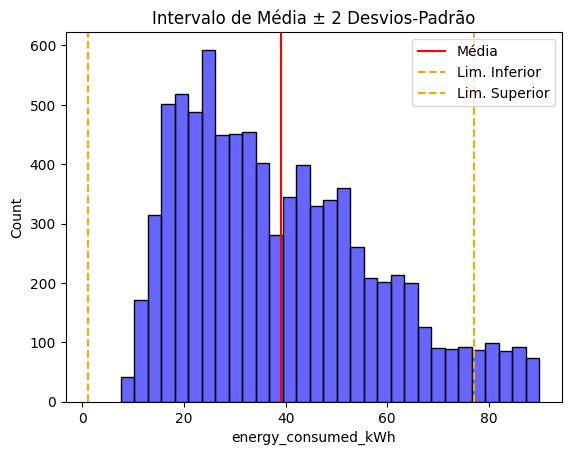

In [24]:
# Gráfico
sns.histplot(consumo_energia, color='blue', alpha=0.6)

plt.axvline(media, color='red', label='Média')
plt.axvline(limite_inferior, color='orange', linestyle='--', label='Lim. Inferior')
plt.axvline(limite_superior, color='orange', linestyle='--', label='Lim. Superior')

plt.title('Intervalo de Média ± 2 Desvios-Padrão')
plt.legend()
plt.show()

# 03) Modelagem com Regressão Linear – 3,0 pontos

Selecione duas variáveis numéricas adequadas e desenvolva um modelo de Regressão Linear em Python, analisando a relação entre elas.

* Implementação correta da Regressão Linear em Python, com uso adequado das bibliotecas e execução sem erros;
* Apresentação do gráfico com os dados e a reta ajustada, contendo título, identificação dos eixos e legenda;
* Interpretação dos coeficientes obtidos no modelo de regressão.


In [25]:
dados_regressao = df[['charging_duration', 'energy_consumed_kWh']].dropna()

print(dados_regressao.head())

   charging_duration  energy_consumed_kWh
0         261.673850            30.528616
1          49.916518            41.504507
2          54.019568            45.016306
3         155.773370            28.291670
4         306.369479            55.810835


In [26]:
X = dados_regressao[['charging_duration']]  # Variável independente (X)
y = dados_regressao['energy_consumed_kWh']   # Variável dependente (y)

In [27]:
X_treino, X_teste, y_treino, y_teste = train_test_split(X, y, test_size=0.20, random_state=42)

In [28]:
# Treinamento do Modelo de Regressão Linear
modelo = LinearRegression()
modelo.fit(X, y)

LinearRegression()

In [29]:
y_pred_teste = modelo.predict(X_teste)

In [30]:
y_pred_total = modelo.predict(X)

In [35]:
# Guardando os coeficientes e métricas
coef_angular = modelo.coef_[0]
intercepto = modelo.intercept_
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
mae = mean_absolute_error(y_teste, y_pred_teste)
mse = mean_squared_error(y_teste, y_pred_teste)
r2 = r2_score(y_teste, y_pred_teste)

### Interpretação dos coeficientes

- **Coeficiente Angular (β1 ≈ 0,0738):** para cada 1 minuto a mais de duração de recarga,
  a energia consumida aumenta, em média, 0,0738 kWh.

- **Intercepto (β0 ≈ 25,89):** é o valor previsto de energia consumida quando a duração é 0 minutos.
  Não tem sentido físico real (recarga de 0 min não consome energia) — é apenas o ponto
  onde a reta corta o eixo Y, necessário para o ajuste matemático do modelo.

- **Relação observada:** existe uma relação positiva entre as duas variáveis (quanto mais tempo
  de recarga, mais energia é consumida), o que é esperado fisicamente.

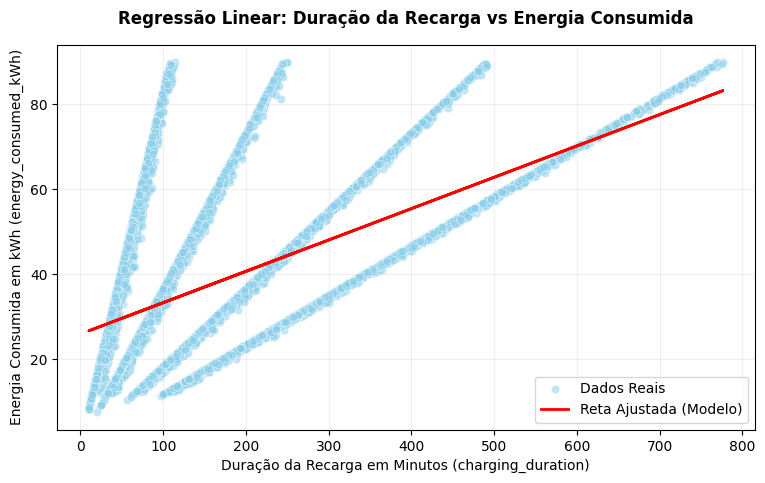

In [36]:
# Gráfico
plt.figure(figsize=(9, 5))

# Gráfico de dispersão com os dados reais
sns.scatterplot(x=dados_regressao['charging_duration'], y=y, color='skyblue', alpha=0.5, label='Dados Reais')

# Linha da regressão ajustada pelo modelo
plt.plot(dados_regressao['charging_duration'], y_pred_total, color='red', linewidth=2, label='Reta Ajustada (Modelo)')

# Configurações obrigatórias de identificação, títulos e eixos
plt.title('Regressão Linear: Duração da Recarga vs Energia Consumida', fontsize=12, fontweight='bold', pad=15)
plt.xlabel('Duração da Recarga em Minutos (charging_duration)', fontsize=10)
plt.ylabel('Energia Consumida em kWh (energy_consumed_kWh)', fontsize=10)
plt.legend()
plt.grid(alpha=0.2)
plt.show()

In [37]:
print(f'Coeficiente Angular (β1): {coef_angular:.4f}')
print(f'Intercepto (β0): {intercepto:.4f}')
print(f'MAE (Erro Absoluto Médio): {mae:.2f}')
print(f'MSE (Erro Quadrático Médio): {mse:.2f}')
print(f'R² (Coeficiente de Determinação): {r2:.4f}')

Coeficiente Angular (β1): 0.0738
Intercepto (β0): 25.8912
MAE (Erro Absoluto Médio): 12.41
MSE (Erro Quadrático Médio): 242.89
R² (Coeficiente de Determinação): 0.3251


### Interpretação Geral

Nos exercícios de probabilidade (1 e 2), assumimos que `energy_consumed_kWh` segue uma
Distribuição Normal, o que permitiu calcular probabilidades teóricas a partir da média e do
desvio-padrão, sem depender apenas da contagem direta dos dados. Os valores teóricos ficaram
próximos dos valores empíricos (contados diretamente na base), o que sugere que a variável
se comporta de forma razoavelmente próxima a uma normal.

No exercício 3, usamos Regressão Linear (um método de Aprendizado de Máquina supervisionado)
para modelar a relação entre `charging_duration` e `energy_consumed_kWh`. Diferente da análise
de probabilidade, que descreve UMA variável isoladamente, a regressão relaciona DUAS variáveis,
permitindo prever uma a partir da outra.

Dessa forma, a estatística (distribuição normal, média, desvio) fornece a base teórica para
entender o comportamento de uma variável isolada, enquanto o Aprendizado de Máquina (regressão)
usa esses mesmos conceitos estatísticos para construir modelos preditivos entre variáveis.